# The sale, end to end

The question is the sale price. The training file has 1460 prices, summing to 264144946, so the mean is $132072473/730$ and the median is 163000. The test file has 1459 houses and no price.

House 1, College Creek, quality 7, has basement $706 + 0 + 150 = 856$ and living area $856 + 854 + 0 = 1710$. It sold for 208500. The living-area line fitted on all 1460 sales prices it near 201762.

`NA` means none for an alley, a pool, a fence, a fireplace, and 81 garages. It means unknown for 259 frontages. Houses 949 and 333 have basements and still carry a basement `NA`.

The quality grade's median rises from 50150 at grade 1 to 432390 at grade 10. A dollar line on that grade predicts a negative price at grade 1. A log line does not.

Ids 524 and 1299 are Edwards partial sales above 4000 square feet, at 184750 and 160000. The area line prices them near 519511 and 622999.

Hold out the 292 houses whose `Id` is divisible by 5. A grade-median table fit on the other 1168 has holdout RMSLE about 0.224. A log line on quality and living area, fit on those same 1168, has holdout RMSLE about 0.183. One quality point on that line multiplies the fitted price by about 1.199. One thousand square feet multiplies it by about 1.272.

Refit that same two-feature line on all 1460 sales, and apply it to test house 1461: North Ames, quality 5, 896 square feet. The line predicts about 117042 dollars. The sample file says 169277.0524984. Neither figure can be graded from these tables.


In [2]:
# Locate the contest tables beside this notebook, or under the course root.
from pathlib import Path
import csv

def manifest_path(name):
    here = Path.cwd()
    for folder in [here, *here.parents]:
        nested = folder / "14-House Prices" / "data" / name
        direct = folder / "data" / name
        if nested.exists():
            return nested
        if direct.exists() and (folder / "data" / "data_description.txt").exists():
            return direct
    raise FileNotFoundError(name)

def read_manifest(name):
    with manifest_path(name).open(newline="", encoding="utf-8") as handle:
        return list(csv.DictReader(handle))

train = read_manifest("train.csv")
test = read_manifest("test.csv")
submission = read_manifest("sample_submission.csv")
print(len(train), len(test), len(submission))
print(train[0]["Id"], train[0]["SalePrice"])


1460 1459 1459
1 208500


In [3]:
# File sizes, house 1, the holdout line, and an unscored prediction for house 1461.
import math
from fractions import Fraction
assert (len(train), len(test), len(submission)) == (1460, 1459, 1459)
prices = [int(row["SalePrice"]) for row in train]
assert sum(prices) == 264144946
assert Fraction(sum(prices), 1460) == Fraction(132072473, 730)
house = train[0]
assert int(house["BsmtFinSF1"]) + int(house["BsmtUnfSF"]) == 856
assert int(house["1stFlrSF"]) + int(house["2ndFlrSF"]) == 1710
assert int(house["SalePrice"]) == 208500

def solve_line(rows):
    columns = ["OverallQual", "GrLivArea"]
    width = 3
    sums = [[0.0 for _ in range(width + 1)] for _ in range(width)]
    for row in rows:
        features = [1.0, float(int(row[columns[0]])), float(int(row[columns[1]]))]
        target = math.log(int(row["SalePrice"]))
        for i in range(width):
            for j in range(width):
                sums[i][j] += features[i] * features[j]
            sums[i][width] += features[i] * target
    for col in range(width):
        pivot = sums[col][col]
        for j in range(col, width + 1):
            sums[col][j] /= pivot
        for i in range(width):
            if i == col:
                continue
            factor = sums[i][col]
            for j in range(col, width + 1):
                sums[i][j] -= factor * sums[col][j]
    return [sums[i][width] for i in range(width)]

def rmsle(predictions, actual):
    total = 0.0
    for pred, price in zip(predictions, actual):
        gap = math.log(pred) - math.log(price)
        total += gap * gap
    return math.sqrt(total / len(actual))

fit_rows = [row for row in train if int(row["Id"]) % 5 != 0]
held_rows = [row for row in train if int(row["Id"]) % 5 == 0]
coefficients = solve_line(fit_rows)
held_pred = [
    math.exp(
        coefficients[0]
        + coefficients[1] * int(row["OverallQual"])
        + coefficients[2] * int(row["GrLivArea"])
    )
    for row in held_rows
]
held_error = rmsle(held_pred, [int(row["SalePrice"]) for row in held_rows])
full = solve_line(train)
test_house = test[0]
test_pred = math.exp(
    full[0]
    + full[1] * int(test_house["OverallQual"])
    + full[2] * int(test_house["GrLivArea"])
)
print(len(fit_rows), len(held_rows), held_error)
print(test_house["Id"], test_house["Neighborhood"], test_pred)
print(submission[0]["SalePrice"])
assert (len(fit_rows), len(held_rows)) == (1168, 292)
assert abs(held_error - 0.182993753517814) < 1e-12
assert test_house["Id"] == "1461"
assert test_house["Neighborhood"] == "NAmes"
assert int(test_house["OverallQual"]) == 5
assert int(test_house["GrLivArea"]) == 896
assert abs(test_pred - 117041.72783635446) < 1e-6
assert "SalePrice" not in test_house


1168 292 0.182993753517814
1461 NAmes 117041.72783635446
169277.0524984


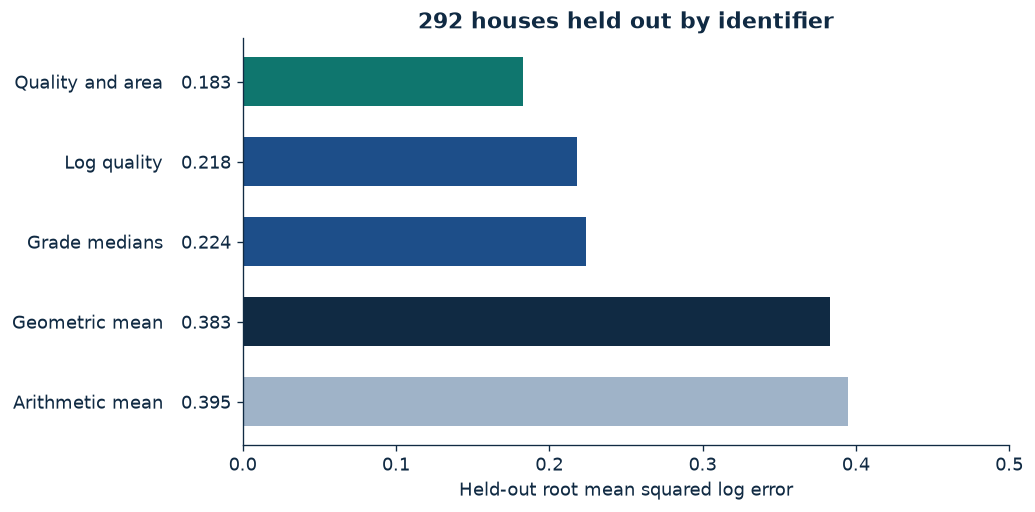

In [4]:
import matplotlib.pyplot as plt
plt.rcParams.update({
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#102a43",
    "axes.labelcolor": "#102a43",
    "xtick.color": "#102a43",
    "ytick.color": "#102a43",
    "text.color": "#102a43",
})
# The holdout scores, from a constant price to the two-feature log line.
labels = [
    "Arithmetic mean   0.395",
    "Geometric mean   0.383",
    "Grade medians   0.224",
    "Log quality   0.218",
    "Quality and area   0.183",
]
scores = [0.394704176512337, 0.3829992574136876, 0.2237289381904309, 0.2184046250138419, 0.182993753517814]
colors = ["#9fb3c8", "#102a43", "#1d4e89", "#1d4e89", "#0f766e"]
figure, axis = plt.subplots(figsize=(8.8, 4.4))
positions = [0, 1, 2, 3, 4]
axis.barh(positions, scores, color=colors, height=0.62)
axis.set_yticks(positions, labels)
axis.set_xlim(0, 0.5)
axis.set_xlabel("Held-out root mean squared log error")
axis.set_title("292 houses held out by identifier")
figure.tight_layout()


## Pitfall

The prediction of about 117042 dollars for house 1461 uses a line fit on all 1460 known sales. There is no price in the test row to compare it with. The 0.183 is a score on 292 other training houses, whose prices the line did not see.

## Summary

Mean $132072473/730$, median 163000, house 1 at 208500. The audited model is $\ln$ price on overall quality and living area. On 292 held-out houses its RMSLE is about 0.183. House 1461 stays ungraded.
